### ***Data Cleaning and Preparation For Risk Classification***

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_excel('/content/drive/MyDrive/ChitwanDataset.xls', engine='xlrd')

In [ ]:
#Code cell to avoid "Groundhog Day"

import os
import pandas as pd

# Define your file path
cleaned_data_path = '/content/drive/MyDrive/chitwan_randomforest.csv'

# Check if the file already exists
if os.path.exists(cleaned_data_path):
    print("Cleaned dataset found! Loading directly from Drive...")
    df_rf = pd.read_csv(cleaned_data_path)
else:
    print("Cleaned dataset not found.")


Cleaned dataset found! Loading directly from Drive...


In [ ]:
#Dropping unnecessary columns
df_rf = df[['Year', 'Month', 'Day', 'LUNAR_DAY',
            'Easting', 'Northing',
            'BZUC', 'Population', 'BZUC_Area_ha',
            'PROBLEM_ANIMAL', 'CONFLICT_TYPE', 'LOSS_INCURRED',
            'HUMAN_LOSS', 'LIVESTOCK_LOSS', 'PROPERTY_LOSS',
            'LOSS_OF_STORED GRAIN', 'CROP_RAIDED', 'TOTAL (NRS)']]


In [ ]:
print(df_rf.shape)
df_rf.head()

(4014, 18)


,Year,Month,Day,LUNAR_DAY,Easting,Northing,BZUC,Population,BZUC_Area_ha,PROBLEM_ANIMAL,CONFLICT_TYPE,LOSS_INCURRED,HUMAN_LOSS,LIVESTOCK_LOSS,PROPERTY_LOSS,LOSS_OF_STORED GRAIN,CROP_RAIDED,TOTAL (NRS)
0,NaN,NaN,NaN,NaN,509345.0,3051257.0,Amaltari,14523.0,2397.9,Rhino,Attacks to human,Human injury,10000,NaN,NaN,NaN,NaN,10000
1,NaN,NaN,NaN,NaN,527333.0,3051436.0,Kerunga,18753.0,2393.2,Unspecified,Attacks to human,Human death,25000,NaN,NaN,NaN,NaN,25000
2,NaN,NaN,NaN,NaN,502788.0,3049807.0,NandaBhauju,11749.0,1658.4,Unspecified,Attacks to human,Human injury,10000,NaN,NaN,NaN,NaN,10000
3,NaN,NaN,NaN,NaN,522510.0,3051230.0,Meghauli,16854.0,3067.2,Unspecified,Attacks to human,Human injury,2000,NaN,NaN,NaN,NaN,2000
4,NaN,NaN,NaN,NaN,557681.0,3026829.0,NirmalThori,12023.0,9503.0,Unspecified,Livestock depredation,Livestock (unspecified),NaN,9500,NaN,NaN,NaN,9500


In [ ]:
# Check how many missing values per column
print(df_rf.isnull().sum())

Year                    1445
Month                   1452
Day                     1452
LUNAR_DAY               1452
Easting                  735
Northing                 735
BZUC                       0
Population               106
BZUC_Area_ha             106
PROBLEM_ANIMAL             0
CONFLICT_TYPE              0
LOSS_INCURRED              0
HUMAN_LOSS              3279
LIVESTOCK_LOSS          1818
PROPERTY_LOSS           3675
LOSS_OF_STORED GRAIN    3900
CROP_RAIDED             3393
TOTAL (NRS)               18
dtype: int64


In [ ]:
# Check unique values for inconsistencies
print(df_rf['PROBLEM_ANIMAL'].unique())
print(df_rf['CONFLICT_TYPE'].unique())

['Rhino' 'Unspecified' 'Tiger' 'Sloth bear' 'Leopard' 'Wild boar'
 'Mugger crocodile' 'Elephant' 'Sambar' 'Python' 'Chital' 'Bluebull'
 'Gaur' 'Sloth Bear' 'Wild Boar']
['Attacks to human' 'Livestock depredation' 'Property damage'
 'Crop loss (storage)' 'Crop Loss (Storage)' 'Crop Loss (Farm)'
 'Crop loss (farm)' 'Property Damage' 'Livestock Depredation']


In [ ]:
df_rf = df_rf.copy()
df_rf['PROBLEM_ANIMAL'] = df_rf['PROBLEM_ANIMAL'].str.strip().str.title()
df_rf['CONFLICT_TYPE'] = df_rf['CONFLICT_TYPE'].str.strip().str.title()

# Verify duplicates are fixed
print(df_rf['PROBLEM_ANIMAL'].unique())
print(df_rf['CONFLICT_TYPE'].unique())

['Rhino' 'Unspecified' 'Tiger' 'Sloth Bear' 'Leopard' 'Wild Boar'
 'Mugger Crocodile' 'Elephant' 'Sambar' 'Python' 'Chital' 'Bluebull'
 'Gaur']
['Attacks To Human' 'Livestock Depredation' 'Property Damage'
 'Crop Loss (Storage)' 'Crop Loss (Farm)']


In [ ]:
#value that decides what animals to choose for wildlife detection
print(df_rf['PROBLEM_ANIMAL'].value_counts())

PROBLEM_ANIMAL
Tiger               1445
Elephant             837
Leopard              668
Rhino                514
Unspecified          264
Sloth Bear           218
Wild Boar             47
Mugger Crocodile       7
Python                 4
Bluebull               3
Chital                 3
Gaur                   3
Sambar                 1
Name: count, dtype: int64


In [ ]:
# Fill loss columns with 0
loss_cols = ['HUMAN_LOSS', 'LIVESTOCK_LOSS', 'PROPERTY_LOSS',
             'LOSS_OF_STORED GRAIN', 'CROP_RAIDED']
df_rf[loss_cols] = df_rf[loss_cols].fillna(0)

df_rf['TOTAL (NRS)'] = df_rf['TOTAL (NRS)'].fillna(0)
df_rf['Population'] = df_rf['Population'].fillna(df_rf['Population'].median())
df_rf['BZUC_Area_ha'] = df_rf['BZUC_Area_ha'].fillna(df_rf['BZUC_Area_ha'].median())

In [ ]:
# Drop rows where coordinates are missing (can't impute these)
df_rf = df_rf.dropna(subset=['Easting', 'Northing', 'Year', 'Month', 'Day'])

In [ ]:
df_rf.head()

,Year,Month,Day,LUNAR_DAY,Easting,Northing,BZUC,Population,BZUC_Area_ha,PROBLEM_ANIMAL,CONFLICT_TYPE,LOSS_INCURRED,HUMAN_LOSS,LIVESTOCK_LOSS,PROPERTY_LOSS,LOSS_OF_STORED GRAIN,CROP_RAIDED,TOTAL (NRS)
1124,2002.0,12.0,1.0,27.0,535750.0,3032377.0,Ayodhyapuri,14206.0,11510.0,Tiger,Livestock Depredation,Goat/sheep,0,750,0,0,0.0,750
1125,2003.0,6.0,13.0,14.0,524732.0,3052042.0,Meghauli,16854.0,3067.2,Leopard,Livestock Depredation,Goat/sheep,0,400,0,0,0.0,400
1126,2003.0,6.0,15.0,16.0,524732.0,3052042.0,Meghauli,16854.0,3067.2,Tiger,Livestock Depredation,Goat/sheep,0,500,0,0,0.0,500
1127,2003.0,4.0,19.0,18.0,553030.0,3027782.0,NirmalThori,12023.0,9503.0,Tiger,Livestock Depredation,Cow/Ox,0,2500,0,0,0.0,2500
1128,2003.0,7.0,13.0,14.0,537333.0,3050960.0,Patihani,7921.0,1951.0,Leopard,Livestock Depredation,Goat/sheep,0,350,0,0,0.0,350


In [ ]:
print(df_rf['HUMAN_LOSS'].value_counts())
print(df_rf['LIVESTOCK_LOSS'].value_counts())
print(df_rf['CROP_RAIDED'].value_counts())

HUMAN_LOSS
0         1753
50000       52
25000       37
150000      30
300000      25
          ... 
10184        1
23965        1
22260        1
8034         1
2630         1
Name: count, Length: 165, dtype: int64
LIVESTOCK_LOSS
0        1093
10000     106
1000       68
2000       53
1500       44
         ... 
5700        1
7800        1
4950        1
34000       1
14200       1
Name: count, Length: 181, dtype: int64
CROP_RAIDED
0.0        1714
5000.0      141
10000.0      67
4000.0       24
3000.0       19
9000.0       18
2000.0       16
8000.0       15
4500.0       15
2800.0       14
1400.0       12
6000.0       11
4200.0        5
1500.0        4
7500.0        3
1600.0        2
2100.0        2
2500.0        2
4300.0        2
1800.0        2
4800.0        2
2400.0        1
2050.0        1
900.0         1
1700.0        1
1200.0        1
1100.0        1
700.0         1
4700.0        1
5400.0        1
5200.0        1
4900.0        1
6200.0        1
9500.0        1
2700.0        1
3500.

In [ ]:
#creating risk level target variable

def assign_risk(row):
    if row['CONFLICT_TYPE'] == 'Attacks To Human':
        return 'HIGH'
    elif row['CONFLICT_TYPE'] in ['Livestock Depredation', 'Property Damage']:
        return 'MEDIUM'
    else:  # Crop Loss (Farm) and Crop Loss (Storage)
        return 'LOW'

df_rf['RISK_LEVEL'] = df_rf.apply(assign_risk, axis=1)
print(df_rf['RISK_LEVEL'].value_counts())

RISK_LEVEL
MEDIUM    1255
LOW        496
HIGH       357
Name: count, dtype: int64


In [ ]:
#verification and saving
print(df_rf.isnull().sum())
print(df_rf.shape)
df_rf.to_csv('/content/drive/MyDrive/chitwan_randomforest.csv', index=False)

Year                    0
Month                   0
Day                     0
LUNAR_DAY               0
Easting                 0
Northing                0
BZUC                    0
Population              0
BZUC_Area_ha            0
PROBLEM_ANIMAL          0
CONFLICT_TYPE           0
LOSS_INCURRED           0
HUMAN_LOSS              0
LIVESTOCK_LOSS          0
PROPERTY_LOSS           0
LOSS_OF_STORED GRAIN    0
CROP_RAIDED             0
TOTAL (NRS)             0
RISK_LEVEL              0
dtype: int64
(2108, 19)


### *Exploratory Data Analysis*

/tmp/ipykernel_18244/1083603688.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='RISK_LEVEL', data=df_rf, order=['LOW', 'MEDIUM', 'HIGH'], palette='viridis')


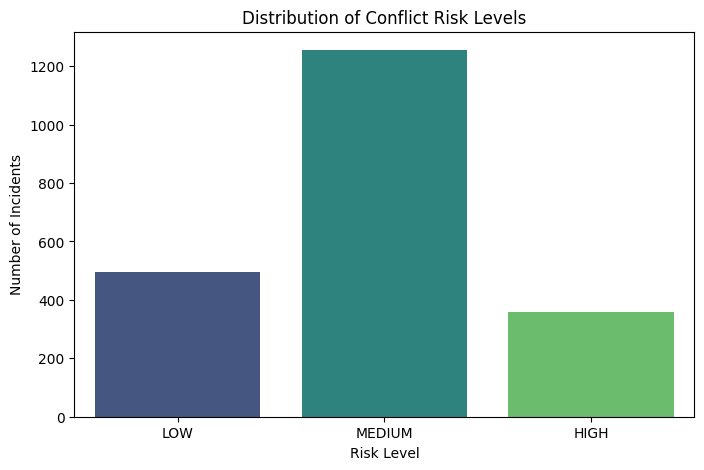

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. VISUALIZE CLASS IMBALANCE
# This shows exactly how many cases are in each risk category
plt.figure(figsize=(8, 5))
sns.countplot(x='RISK_LEVEL', data=df_rf, order=['LOW', 'MEDIUM', 'HIGH'], palette='viridis')
plt.title('Distribution of Conflict Risk Levels')
plt.xlabel('Risk Level')
plt.ylabel('Number of Incidents')
plt.show()

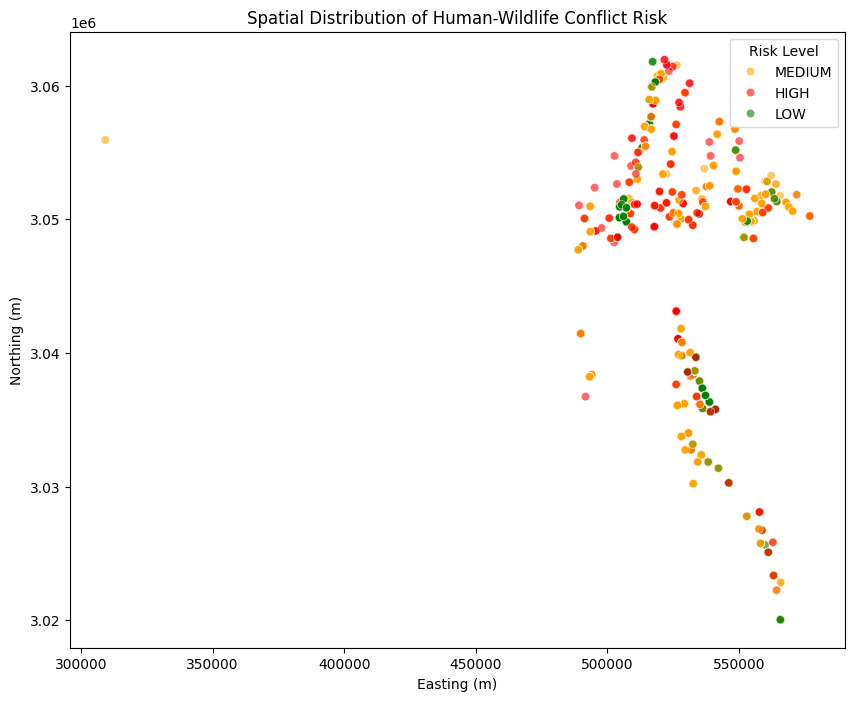

In [ ]:
# 2. SPATIAL HOTSPOT IDENTIFICATION
# Plots Easting and Northing to see where 'HIGH' risk incidents cluster
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_rf, x='Easting', y='Northing', hue='RISK_LEVEL',
                palette={'HIGH': 'red', 'MEDIUM': 'orange', 'LOW': 'green'},
                alpha=0.6)
plt.title('Spatial Distribution of Human-Wildlife Conflict Risk')
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.legend(title='Risk Level')
plt.show()

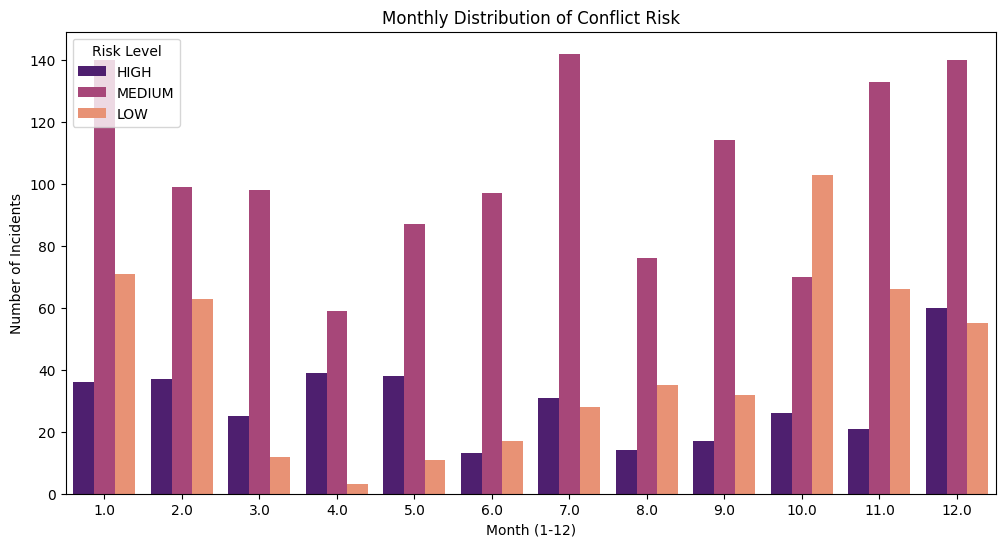

In [ ]:
# 3. TEMPORAL PATTERN ANALYSIS (MONTHLY)
# Shows which months have the highest frequency of severe conflicts
plt.figure(figsize=(12, 6))
sns.countplot(data=df_rf, x='Month', hue='RISK_LEVEL', palette='magma')
plt.title('Monthly Distribution of Conflict Risk')
plt.xlabel('Month (1-12)')
plt.ylabel('Number of Incidents')
plt.legend(title='Risk Level')
plt.show()

/tmp/ipykernel_18244/3896969027.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rf, x='RISK_LEVEL', y='LUNAR_DAY', order=['LOW', 'MEDIUM', 'HIGH'], palette='coolwarm')


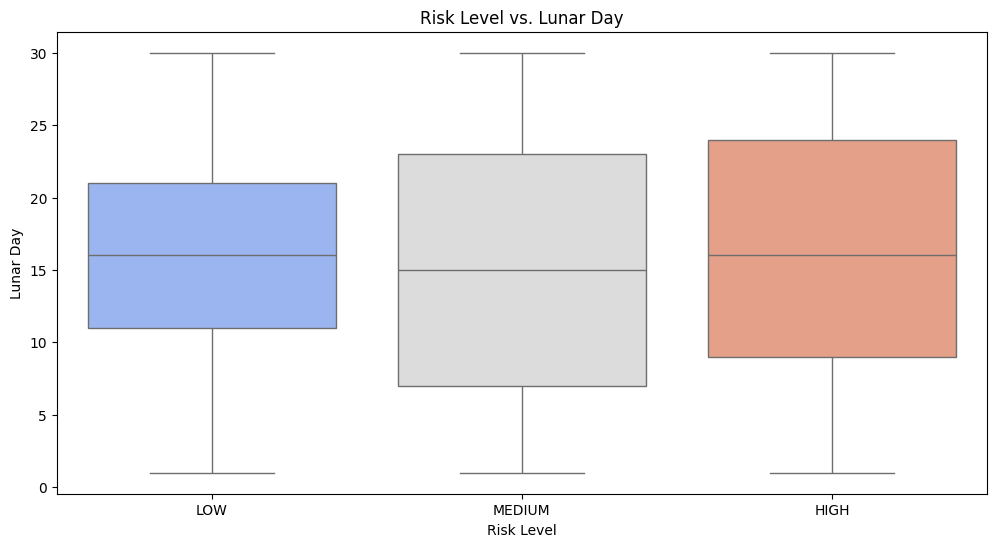

In [ ]:
# 4. LUNAR CYCLE ANALYSIS
# Checks if the Lunar Day affects the severity of incidents
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_rf, x='RISK_LEVEL', y='LUNAR_DAY', order=['LOW', 'MEDIUM', 'HIGH'], palette='coolwarm')
plt.title('Risk Level vs. Lunar Day')
plt.xlabel('Risk Level')
plt.ylabel('Lunar Day')
plt.show()

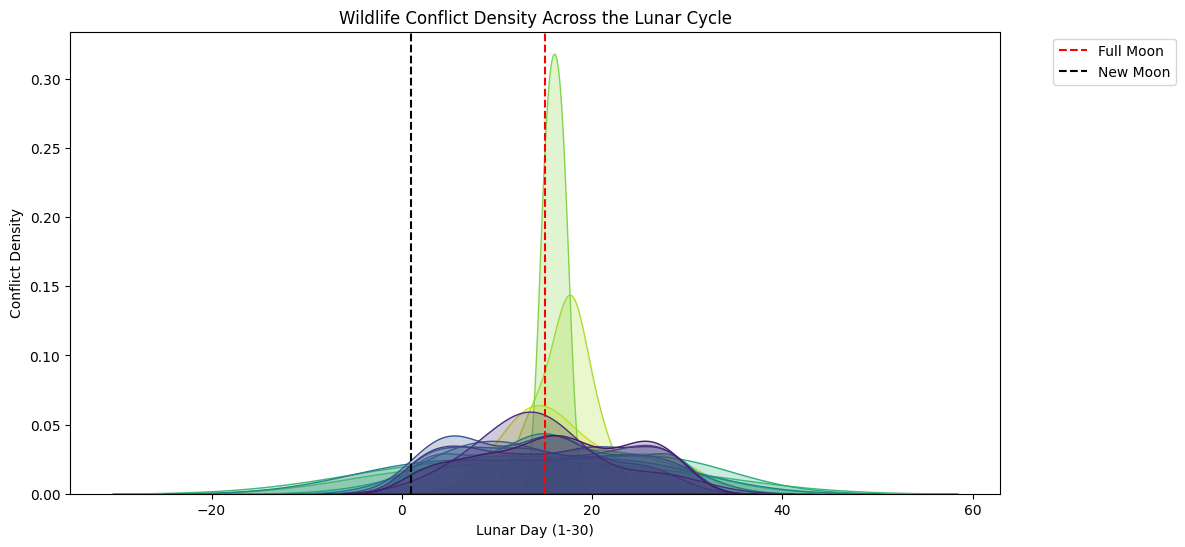

In [ ]:
# 5. Lunar Day Pattern Recognition
# Plotting incidents across the Lunar Cycle
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x='LUNAR_DAY', hue='PROBLEM_ANIMAL', fill=True, common_norm=False, palette='viridis')
plt.axvline(15, color='red', linestyle='--', label='Full Moon')
plt.axvline(1, color='black', linestyle='--', label='New Moon')
plt.title('Wildlife Conflict Density Across the Lunar Cycle')
plt.xlabel('Lunar Day (1-30)')
plt.ylabel('Conflict Density')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

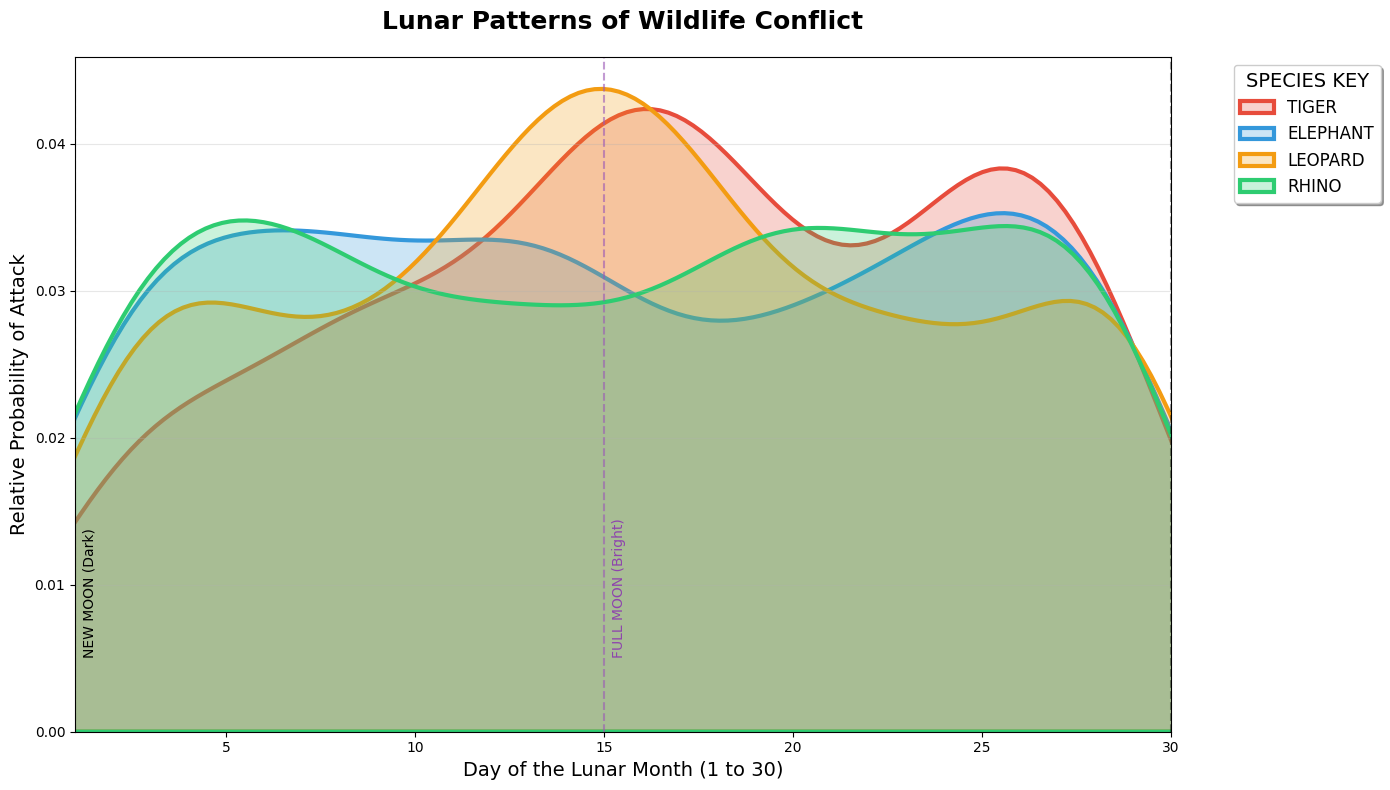

In [ ]:
# 6. Species-Specific Conflict Patterns

# Standardizing the animal names
df['PROBLEM_ANIMAL'] = df['PROBLEM_ANIMAL'].str.strip().str.upper()

target_animals = ['TIGER', 'ELEPHANT', 'LEOPARD', 'RHINO']
df_subset = df[df['PROBLEM_ANIMAL'].isin(target_animals)].copy()

# Cutomize

custom_colors = {
    'TIGER': '#2ecc71',    # Red (Danger/Predator)
    'ELEPHANT': '#f39c12', # Blue
    'LEOPARD': '#3498db',  # Orange
    'RHINO': '#e74c3c'     # Green
}

plt.figure(figsize=(14, 8))

# Create the Plot with the explicit color map
sns.kdeplot(
    data=df_subset,
    x='LUNAR_DAY',
    hue='PROBLEM_ANIMAL',
    palette=custom_colors,
    hue_order=target_animals, # Ensures the legend follows this order
    fill=True,
    alpha=0.25,
    linewidth=3,
    common_norm=False
)

# Adding Clear Lunar Landmark Lines
plt.axvline(1, color='black', linestyle='--', alpha=0.4)
plt.text(1.2, 0.005, 'NEW MOON (Dark)', rotation=90, verticalalignment='bottom', fontsize=10)

plt.axvline(15, color='#9b59b6', linestyle='--', alpha=0.6)
plt.text(15.2, 0.005, 'FULL MOON (Bright)', rotation=90, verticalalignment='bottom', fontsize=10, color='#8e44ad')

plt.axvline(30, color='black', linestyle='--', alpha=0.4)

# Legend plot
plt.legend(
    title='SPECIES KEY',
    labels=['TIGER', 'ELEPHANT', 'LEOPARD', 'RHINO'],
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=12,
    title_fontsize=14,
    frameon=True,
    shadow=True
)

plt.title('Lunar Patterns of Wildlife Conflict', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Day of the Lunar Month (1 to 30)', fontsize=14)
plt.ylabel('Relative Probability of Attack', fontsize=14)
plt.xlim(1, 30)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

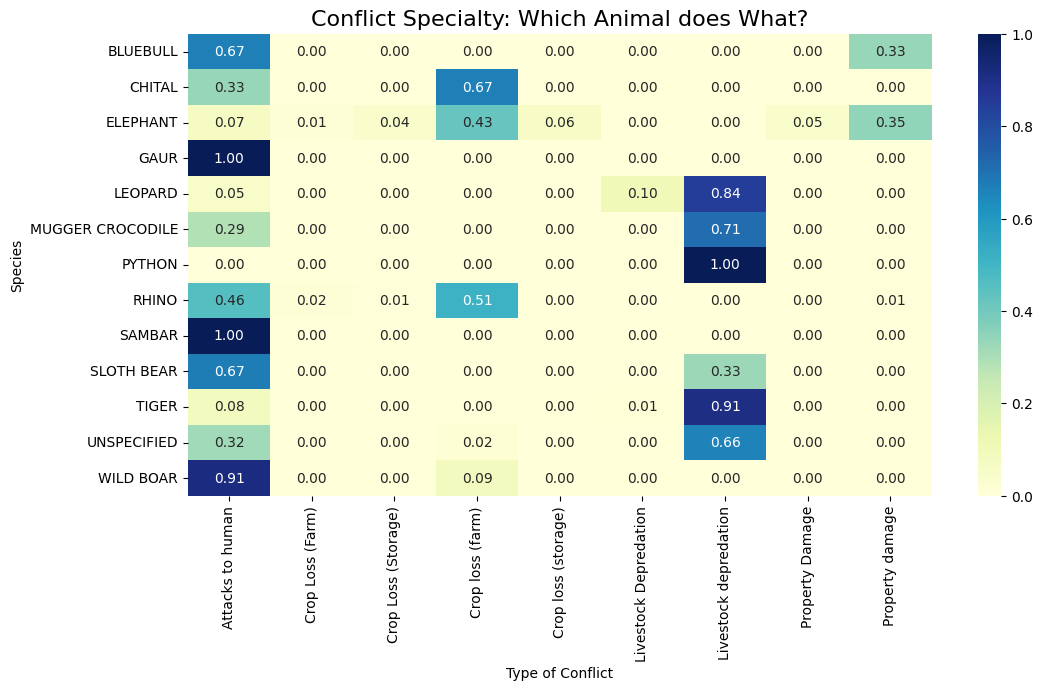

In [ ]:
# 7. The "Attack Type" Heatmap (What happens when?)

# Cross-tabulate Animal vs Conflict Type
conflict_pattern = pd.crosstab(df['PROBLEM_ANIMAL'], df['CONFLICT_TYPE'], normalize='index')

plt.figure(figsize=(12, 6))
sns.heatmap(conflict_pattern, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Conflict Specialty: Which Animal does What?', fontsize=16)
plt.ylabel('Species')
plt.xlabel('Type of Conflict')
plt.show()

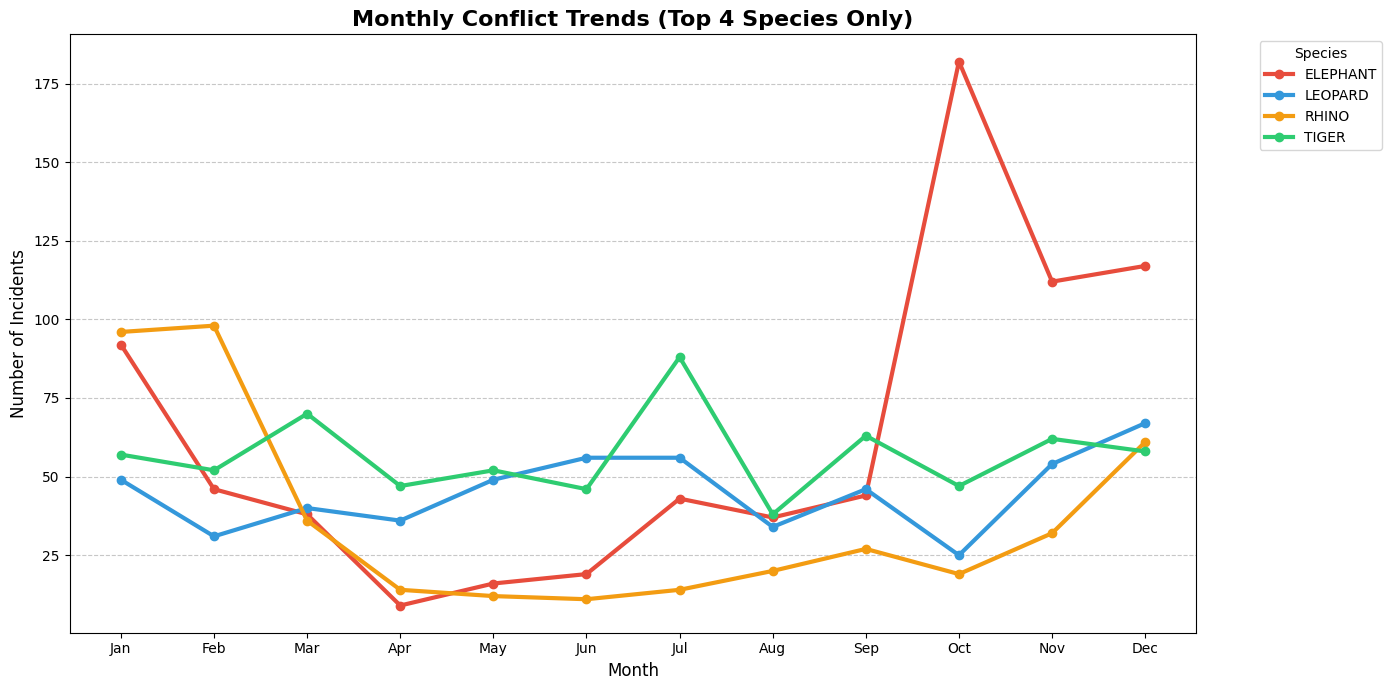

In [ ]:
# 8. Seasonality vs. Animal Type (The "Calendar" Pattern)
# which animal attacks more in what season

# Filter for the Top 4 species
top_4_species = df['PROBLEM_ANIMAL'].value_counts().nlargest(4).index.tolist()
df_seasonal = df[df['PROBLEM_ANIMAL'].isin(top_4_species)].copy()

# Pivot the data
seasonal_pivot = df_seasonal.groupby(['Month', 'PROBLEM_ANIMAL']).size().unstack(fill_value=0)

# Plot with specific colors and clearer lines
plt.figure(figsize=(14, 7))
seasonal_pivot.plot(kind='line', marker='o', ax=plt.gca(), linewidth=3, color=['#e74c3c', '#3498db', '#f39c12', '#2ecc71'])

plt.title('Monthly Conflict Trends (Top 4 Species Only)', fontsize=16, fontweight='bold')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.ylabel('Number of Incidents', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

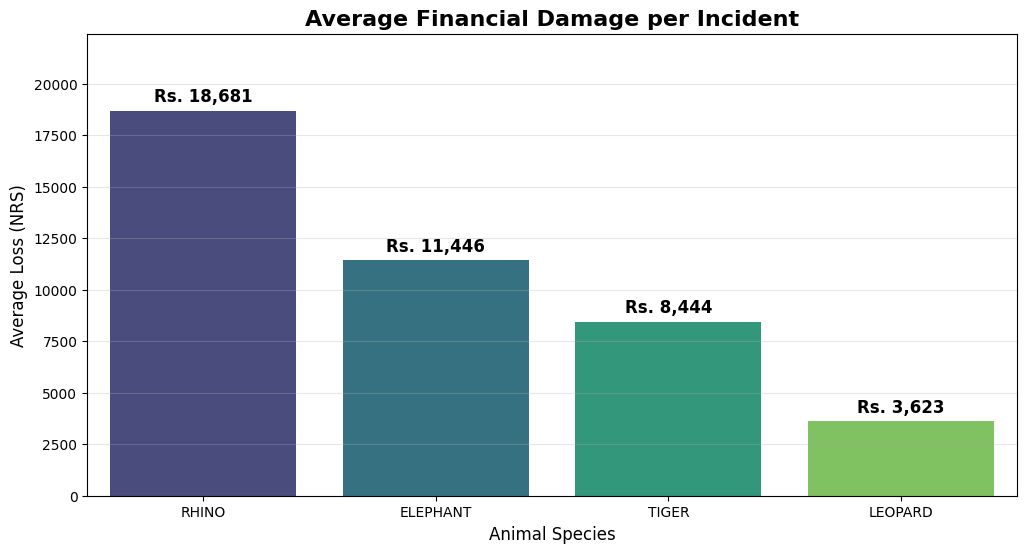

Final Money Values:
PROBLEM_ANIMAL
RHINO       18681.472763
ELEPHANT    11446.088411
TIGER        8444.183003
LEOPARD      3622.825898
Name: REAL_LOSS, dtype: float64


In [ ]:
# 9. The "Financial Severity" Pattern
# Not all conflicts are equal. A Tiger killing a cow is a different financial blow than an Elephant trampling a fence.

# Standardize column names to remove hidden spaces
df.columns = df.columns.str.strip()

# CREATE A CLEAN MONEY COLUMN
# We will look for 'TOTAL (NRS)' or use 'LOSS_INCURRED' if it contains numbers.
# This line forces everything into numbers and turns "Paddy/Goat" into 'NaN' (empty).
df['REAL_LOSS'] = pd.to_numeric(df['TOTAL (NRS)'], errors='coerce')

# If 'TOTAL (NRS)' didn't exist, try to fix the 'LOSS_INCURRED' column itself
if df['REAL_LOSS'].isna().all():
    df['REAL_LOSS'] = pd.to_numeric(df['LOSS_INCURRED'], errors='coerce')

# Fill empty spots with 0 so the math doesn't break
df['REAL_LOSS'] = df['REAL_LOSS'].fillna(0)

# Filter for our main animals
target_animals = ['TIGER', 'ELEPHANT', 'LEOPARD', 'RHINO']
df_clean = df[df['PROBLEM_ANIMAL'].str.strip().str.upper().isin(target_animals)].copy()

# Calculate Average Loss (ONLY on the numeric column)
# This prevents the "TypeError: int + str"
avg_loss = df_clean.groupby('PROBLEM_ANIMAL')['REAL_LOSS'].mean().sort_values(ascending=False)

# PLOT REAL MONEY
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=avg_loss.index, y=avg_loss.values, palette='viridis', hue=avg_loss.index, legend=False)

# Add clear labels on top of bars
for p in ax.patches:
    ax.annotate(f'Rs. {p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points',
                fontsize=12, fontweight='bold', color='black')

plt.title('Average Financial Damage per Incident', fontsize=16, fontweight='bold')
plt.ylabel('Average Loss (NRS)', fontsize=12)
plt.xlabel('Animal Species', fontsize=12)
plt.ylim(0, avg_loss.max() * 1.2) # Add space for the labels
plt.grid(axis='y', alpha=0.3)
plt.show()

print("Final Money Values:")
print(avg_loss)